**BO1: Aide les entreprises à anticiper les métiers à recruter et adapter leurs plans RH et formation**
Classifier des métiers selon trajectoire 2024→2030(croissance / stable / déclin).

knn - tree, XGBoost, Logistic Regression

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from sklearn.preprocessing import LabelEncoder,PolynomialFeatures,StandardScaler
from scipy.stats import randint, uniform
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, StratifiedKFold,KFold, RandomizedSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix, 
                           precision_score, recall_score, f1_score, precision_recall_fscore_support,
                           balanced_accuracy_score, make_scorer,roc_curve, roc_auc_score)
from sklearn.tree import DecisionTreeClassifier, plot_tree
from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings('ignore')

**Load the prepared dataset**

In [2]:
df =  pd.read_csv(r"C:\Users\meria\Desktop\ING\mlProject\prepared_data.csv")
print(f"Dataset shape: {df.shape}")


if "Job_Status" not in df.columns:
    raise ValueError("Colonne Job_Status manquante")
print("Target trouvée: Job_Status")

Dataset shape: (10000, 15)
Target trouvée: Job_Status


In [3]:
target = "Job_Status"

LEAKAGE_FEATURES = ['Job_Status','Job_Growth_Rate_%','Growth_Category']
X = df.select_dtypes(include=[np.number]).drop(columns=LEAKAGE_FEATURES, errors="ignore")

y = df["Job_Status"].map({"decreasing": 0, "increasing": 1}).astype(int)
print("\nTarget distribution:")
print(y.value_counts(normalize=True))
class_names = ["decreasing", "increasing"]


Target distribution:
Job_Status
0    0.5019
1    0.4981
Name: proportion, dtype: float64


**Split the data**

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"\nData Split:")
print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")
print(f"Training target distribution: {dict(zip(class_names, np.bincount(y_train)))}")


Data Split:
Training set: (8000, 11)
Test set: (2000, 11)
Training target distribution: {'decreasing': np.int64(4015), 'increasing': np.int64(3985)}


In [5]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# **KNN**

In [6]:
knn_baseline = KNeighborsClassifier(n_neighbors=7)
knn_baseline.fit(X_train_scaled, y_train)
y_pred_knn = knn_baseline.predict(X_test_scaled)
acc_knn= accuracy_score(y_test, y_pred_knn)

print(f" KNN Baseline - Accuracy: {acc_knn:.3f}")
print("\nRapport de classification KNN basique :")
print(classification_report(y_test, y_pred_knn))


 KNN Baseline - Accuracy: 0.503

Rapport de classification KNN basique :
              precision    recall  f1-score   support

           0       0.51      0.51      0.51      1004
           1       0.50      0.50      0.50       996

    accuracy                           0.50      2000
   macro avg       0.50      0.50      0.50      2000
weighted avg       0.50      0.50      0.50      2000



**Optimisation KNN avec GridSearchCV**

In [7]:
param_grid_knn = {
    'n_neighbors': [3, 5, 7, 9, 11, 15],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}
knn_grid = GridSearchCV(
    KNeighborsClassifier(), 
    param_grid_knn, 
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='accuracy',
    n_jobs=-1
)
knn_grid.fit(X_train, y_train)   
best_knn = knn_grid.best_estimator_
y_pred_knn_opt = best_knn.predict(X_test)
acc_knn_opt = accuracy_score(y_test, y_pred_knn_opt)

**evaluation**

In [8]:
print(f" KNN OPTIMISÉ - Performances:")
print(f"   • Accuracy: {acc_knn_opt:.4f}")
print(f"   • Meilleurs paramètres: {knn_grid.best_params_}")
print("\nRapport de classification KNN optimisé :")
print(classification_report(y_test, y_pred_knn_opt, target_names=class_names))


 KNN OPTIMISÉ - Performances:
   • Accuracy: 0.4985
   • Meilleurs paramètres: {'metric': 'manhattan', 'n_neighbors': 9, 'weights': 'uniform'}

Rapport de classification KNN optimisé :
              precision    recall  f1-score   support

  decreasing       0.50      0.51      0.50      1004
  increasing       0.50      0.49      0.49       996

    accuracy                           0.50      2000
   macro avg       0.50      0.50      0.50      2000
weighted avg       0.50      0.50      0.50      2000



**visualisation**

**Matrice de confusion**

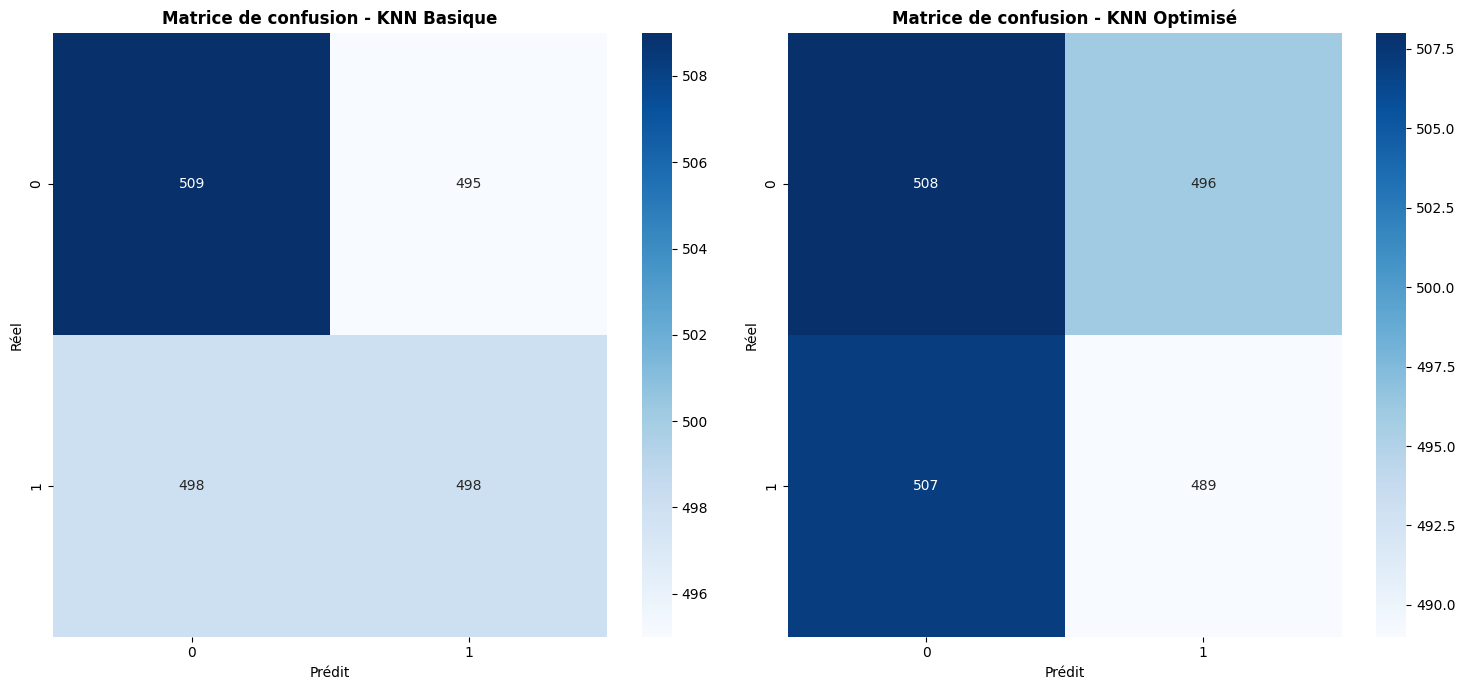

In [9]:
plt.figure(figsize=(15, 7))
plt.subplot(1, 2, 1)
cm_basic = confusion_matrix(y_test, y_pred_knn)
sns.heatmap(cm_basic, annot=True, fmt='d', cmap='Blues')  
plt.title("Matrice de confusion - KNN Basique", fontweight='bold')
plt.xlabel('Prédit')
plt.ylabel('Réel')

plt.subplot(1, 2, 2)
cm_opt = confusion_matrix(y_test, y_pred_knn_opt)
sns.heatmap(cm_opt, annot=True, fmt='d', cmap='Blues') 
plt.title("Matrice de confusion - KNN Optimisé", fontweight='bold')
plt.xlabel('Prédit')
plt.ylabel('Réel')
plt.tight_layout()
plt.show()

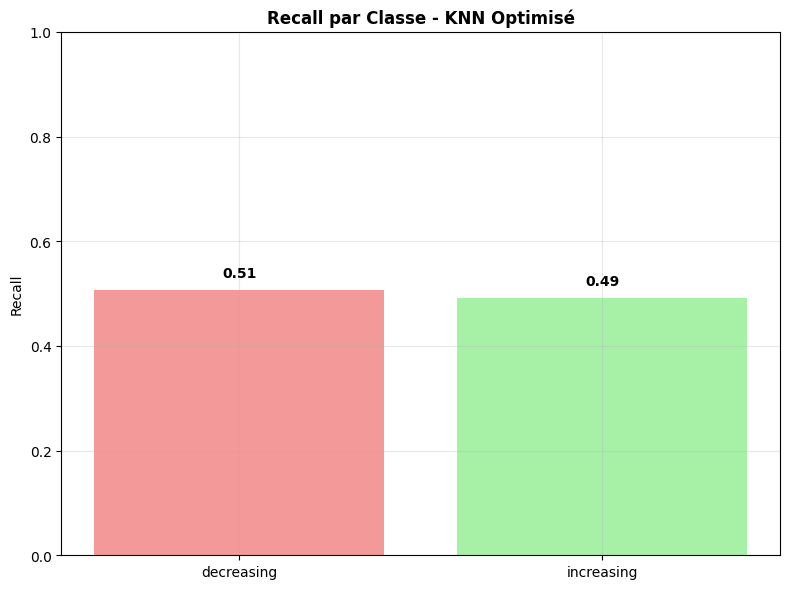

In [10]:
plt.figure(figsize=(8, 6))
recall_knn = recall_score(y_test, y_pred_knn_opt, average=None)
x_pos = np.arange(len(class_names))
plt.bar(x_pos, recall_knn, color=['lightcoral', 'lightgreen'], alpha=0.8)  
plt.title('Recall par Classe - KNN Optimisé', fontweight='bold')
plt.ylabel('Recall')
plt.xticks(x_pos, class_names)
plt.ylim(0, 1)
for i, v in enumerate(recall_knn):
    plt.text(i, v + 0.02, f'{v:.2f}', ha='center', va='bottom', fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

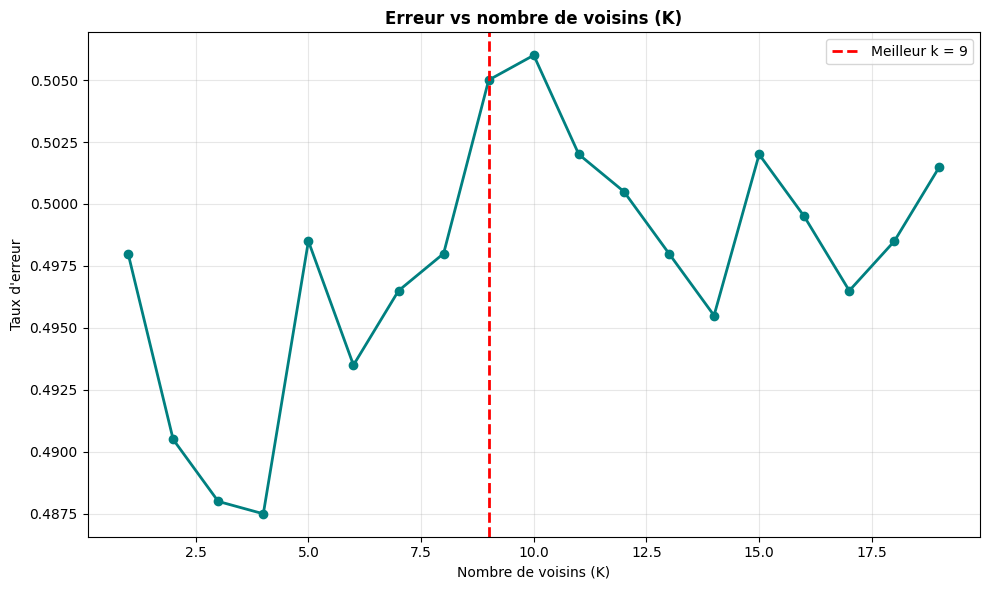

In [11]:
plt.figure(figsize=(10, 6))
errors = []
neighbors_range = range(1, 20)
for k in neighbors_range:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train_scaled, y_train)
    pred_k = model.predict(X_test_scaled)
    errors.append(1 - accuracy_score(y_test, pred_k))

plt.plot(neighbors_range, errors, marker='o', linestyle='-', color='teal', linewidth=2, markersize=6)
plt.axvline(x=knn_grid.best_params_['n_neighbors'], color='red', linestyle='--', 
            label=f'Meilleur k = {knn_grid.best_params_["n_neighbors"]}', linewidth=2)
plt.title("Erreur vs nombre de voisins (K)", fontweight='bold')
plt.xlabel("Nombre de voisins (K)")
plt.ylabel("Taux d'erreur")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# **Modèle Arbre de Décision** 


In [12]:
tree_baseline = DecisionTreeClassifier(random_state=42)
tree_baseline.fit(X_train, y_train)
y_pred_tree= tree_baseline.predict(X_test)
acc_tree= accuracy_score(y_test, y_pred_tree)

In [13]:

print(f"Arbre Baseline (défaut) - Accuracy: {acc_tree:.3f}")
print(f"   • Profondeur: {tree_baseline.get_depth()}")
print(f"   • Feuilles: {tree_baseline.get_n_leaves()}")

Arbre Baseline (défaut) - Accuracy: 0.512
   • Profondeur: 33
   • Feuilles: 1998


**Optimisation Arbre avec GridSearchCV**

In [14]:
param_grid_tree = {
    'max_depth': [5, 10, 15, 20, None],
    'min_samples_split': [10, 20, 50],
    'min_samples_leaf': [5, 10, 20],
    'criterion': ['gini', 'entropy'],
    'max_features': ['sqrt', 'log2', None]
}

grid_search_tree = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid_tree,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='balanced_accuracy',
    n_jobs=-1,
    verbose=1
)
grid_search_tree.fit(X_train, y_train)  

best_tree = grid_search_tree.best_estimator_
y_pred_tree = best_tree.predict(X_test)
acc_tree = accuracy_score(y_test, y_pred_tree)

Fitting 5 folds for each of 270 candidates, totalling 1350 fits


In [15]:
print(f"ARBRE OPTIMISÉ - Performances:")
print(f"  • Accuracy: {acc_tree:.4f}")
print(f"  • Meilleurs paramètres: {grid_search_tree.best_params_}")
print("\nRapport de classification Arbre optimisé :")
print(classification_report(y_test, y_pred_tree))

ARBRE OPTIMISÉ - Performances:
  • Accuracy: 0.4715
  • Meilleurs paramètres: {'criterion': 'gini', 'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 20, 'min_samples_split': 10}

Rapport de classification Arbre optimisé :
              precision    recall  f1-score   support

           0       0.47      0.39      0.42      1004
           1       0.47      0.56      0.51       996

    accuracy                           0.47      2000
   macro avg       0.47      0.47      0.47      2000
weighted avg       0.47      0.47      0.47      2000



**Validation Croisée Arbre**


In [16]:
cv_scores_tree = cross_val_score(best_tree, X_train, y_train, cv=5, scoring='accuracy')
print(f"\nVALIDATION CROISÉE ARBRE:")
print(f"  • Scores CV: {[f'{s:.4f}' for s in cv_scores_tree]}")
print(f"  • Moyenne:   {cv_scores_tree.mean():.4f} (± {cv_scores_tree.std():.4f})")



VALIDATION CROISÉE ARBRE:
  • Scores CV: ['0.5175', '0.5012', '0.5181', '0.4906', '0.5175']
  • Moyenne:   0.5090 (± 0.0112)


In [17]:
# Importance des features
importances_tree = pd.Series(best_tree.feature_importances_, index=X.columns)
importances_tree = importances_tree.sort_values(ascending=False)
top_features_tree = importances_tree[importances_tree > 0].head(15)

print(f"\nTOP {len(top_features_tree)} FEATURES IMPORTANTES - ARBRE:")
for i, (feature, importance) in enumerate(top_features_tree.items(), 1):
    print(f"   {i:2d}. {feature:35} {importance:7.4f} ")


TOP 11 FEATURES IMPORTANTES - ARBRE:
    1. Automation_Risk_%                    0.1738 
    2. Gender_Diversity_%                   0.1678 
    3. Vulnerability_Index                  0.1262 
    4. Remote_Work_Ratio_%                  0.1259 
    5. Job_Value_Index                      0.1098 
    6. Median_Salary_USD                    0.0792 
    7. Education_Level                      0.0644 
    8. Experience_Required_Years            0.0558 
    9. Location                             0.0347 
   10. Industry                             0.0333 
   11. AI_Impact_Level                      0.0290 


**Visualisations Arbre**


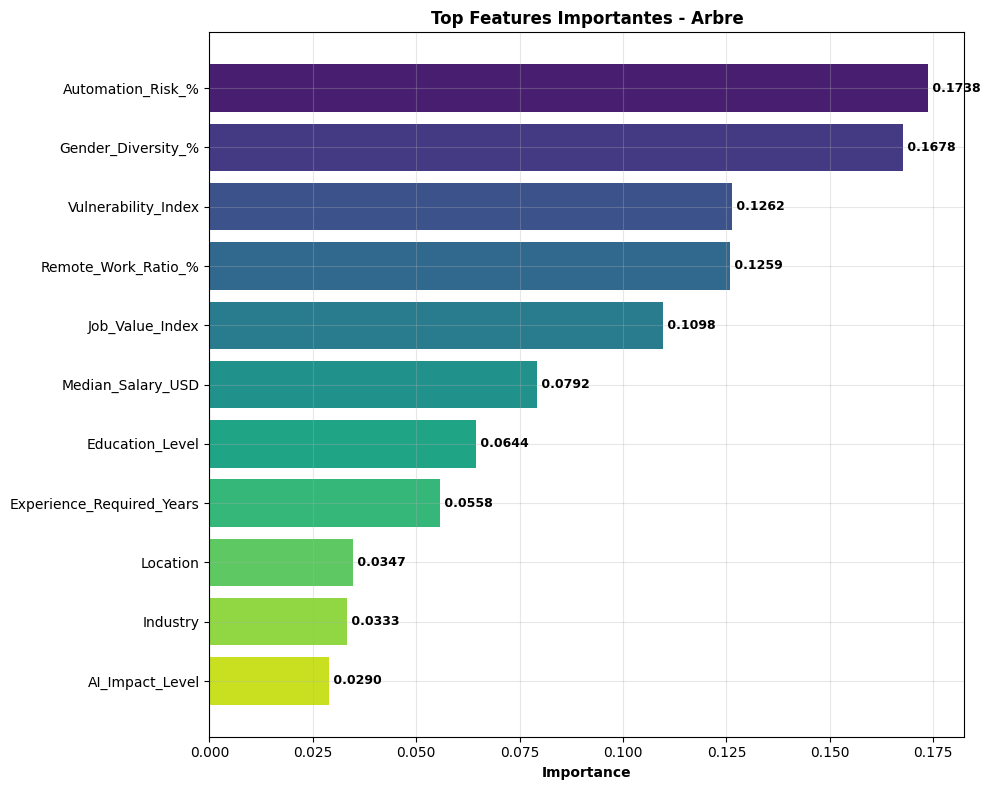

In [18]:
plt.figure(figsize=(10, 8))
colors = sns.color_palette("viridis", len(top_features_tree))
bars = plt.barh(range(len(top_features_tree)), top_features_tree.values, color=colors)
plt.yticks(range(len(top_features_tree)), top_features_tree.index)
plt.xlabel('Importance', fontweight='bold')
plt.title('Top Features Importantes - Arbre', fontweight='bold')
plt.gca().invert_yaxis()
for i, (bar, val) in enumerate(zip(bars, top_features_tree.values)):
    plt.text(val, i, f' {val:.4f}', va='center', fontsize=9, fontweight='bold')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

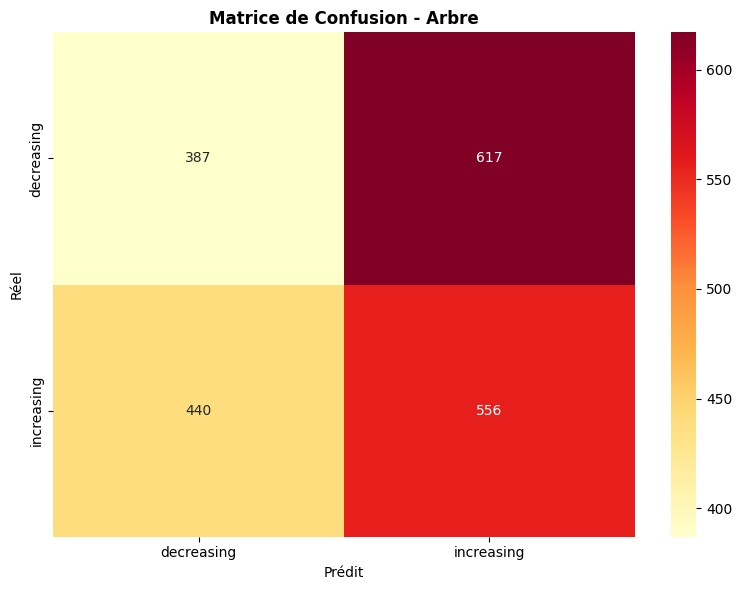

In [19]:
# Matrice de confusion Arbre
plt.figure(figsize=(8, 6))
cm_tree = confusion_matrix(y_test, y_pred_tree)
sns.heatmap(cm_tree, annot=True, fmt='d', cmap='YlOrRd',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Matrice de Confusion - Arbre', fontweight='bold')
plt.xlabel('Prédit')
plt.ylabel('Réel')
plt.tight_layout()
plt.show()

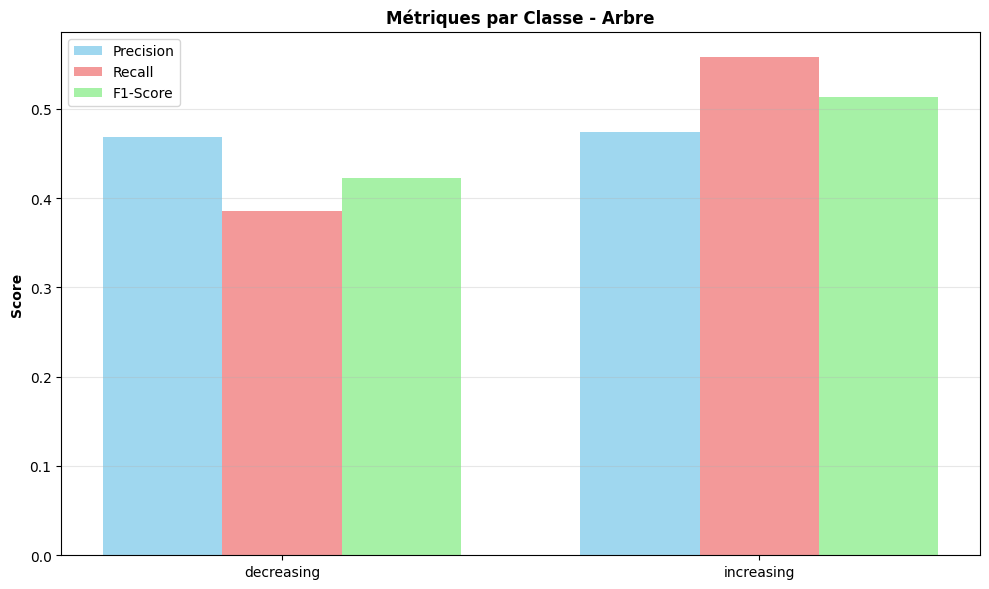

In [20]:
plt.figure(figsize=(10, 6))
precision_tree, recall_tree, f1_tree, _ = precision_recall_fscore_support(y_test, y_pred_tree, average=None)
x_pos = np.arange(len(class_names))
width = 0.25
plt.bar(x_pos - width, precision_tree, width, label='Precision', alpha=0.8, color='skyblue')
plt.bar(x_pos, recall_tree, width, label='Recall', alpha=0.8, color='lightcoral')
plt.bar(x_pos + width, f1_tree, width, label='F1-Score', alpha=0.8, color='lightgreen')
plt.ylabel('Score', fontweight='bold')
plt.title('Métriques par Classe - Arbre', fontweight='bold')
plt.xticks(x_pos, class_names)
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


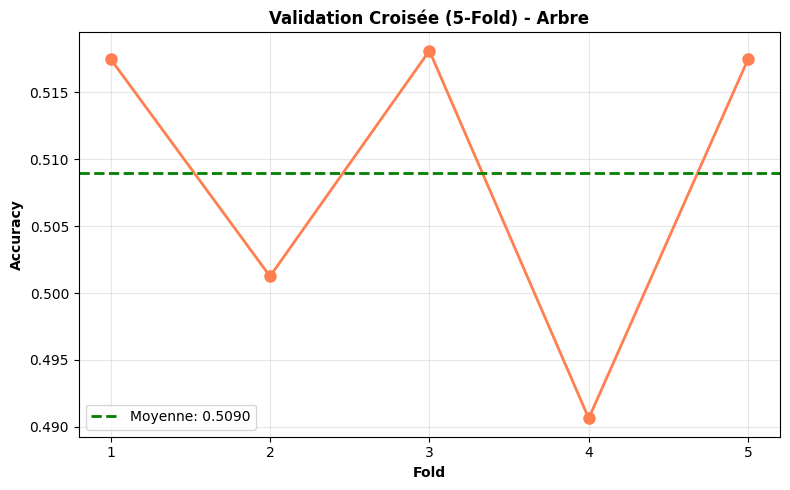

In [21]:
# Cross-validation plot
plt.figure(figsize=(8, 5))
plt.plot(range(1, 6), cv_scores_tree, 'o-', linewidth=2, markersize=8, color='coral')
plt.axhline(cv_scores_tree.mean(), color='green', linestyle='--', 
           label=f'Moyenne: {cv_scores_tree.mean():.4f}', linewidth=2)
plt.xlabel('Fold', fontweight='bold')
plt.ylabel('Accuracy', fontweight='bold')
plt.title('Validation Croisée (5-Fold) - Arbre', fontweight='bold')
plt.xticks(range(1, 6))
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

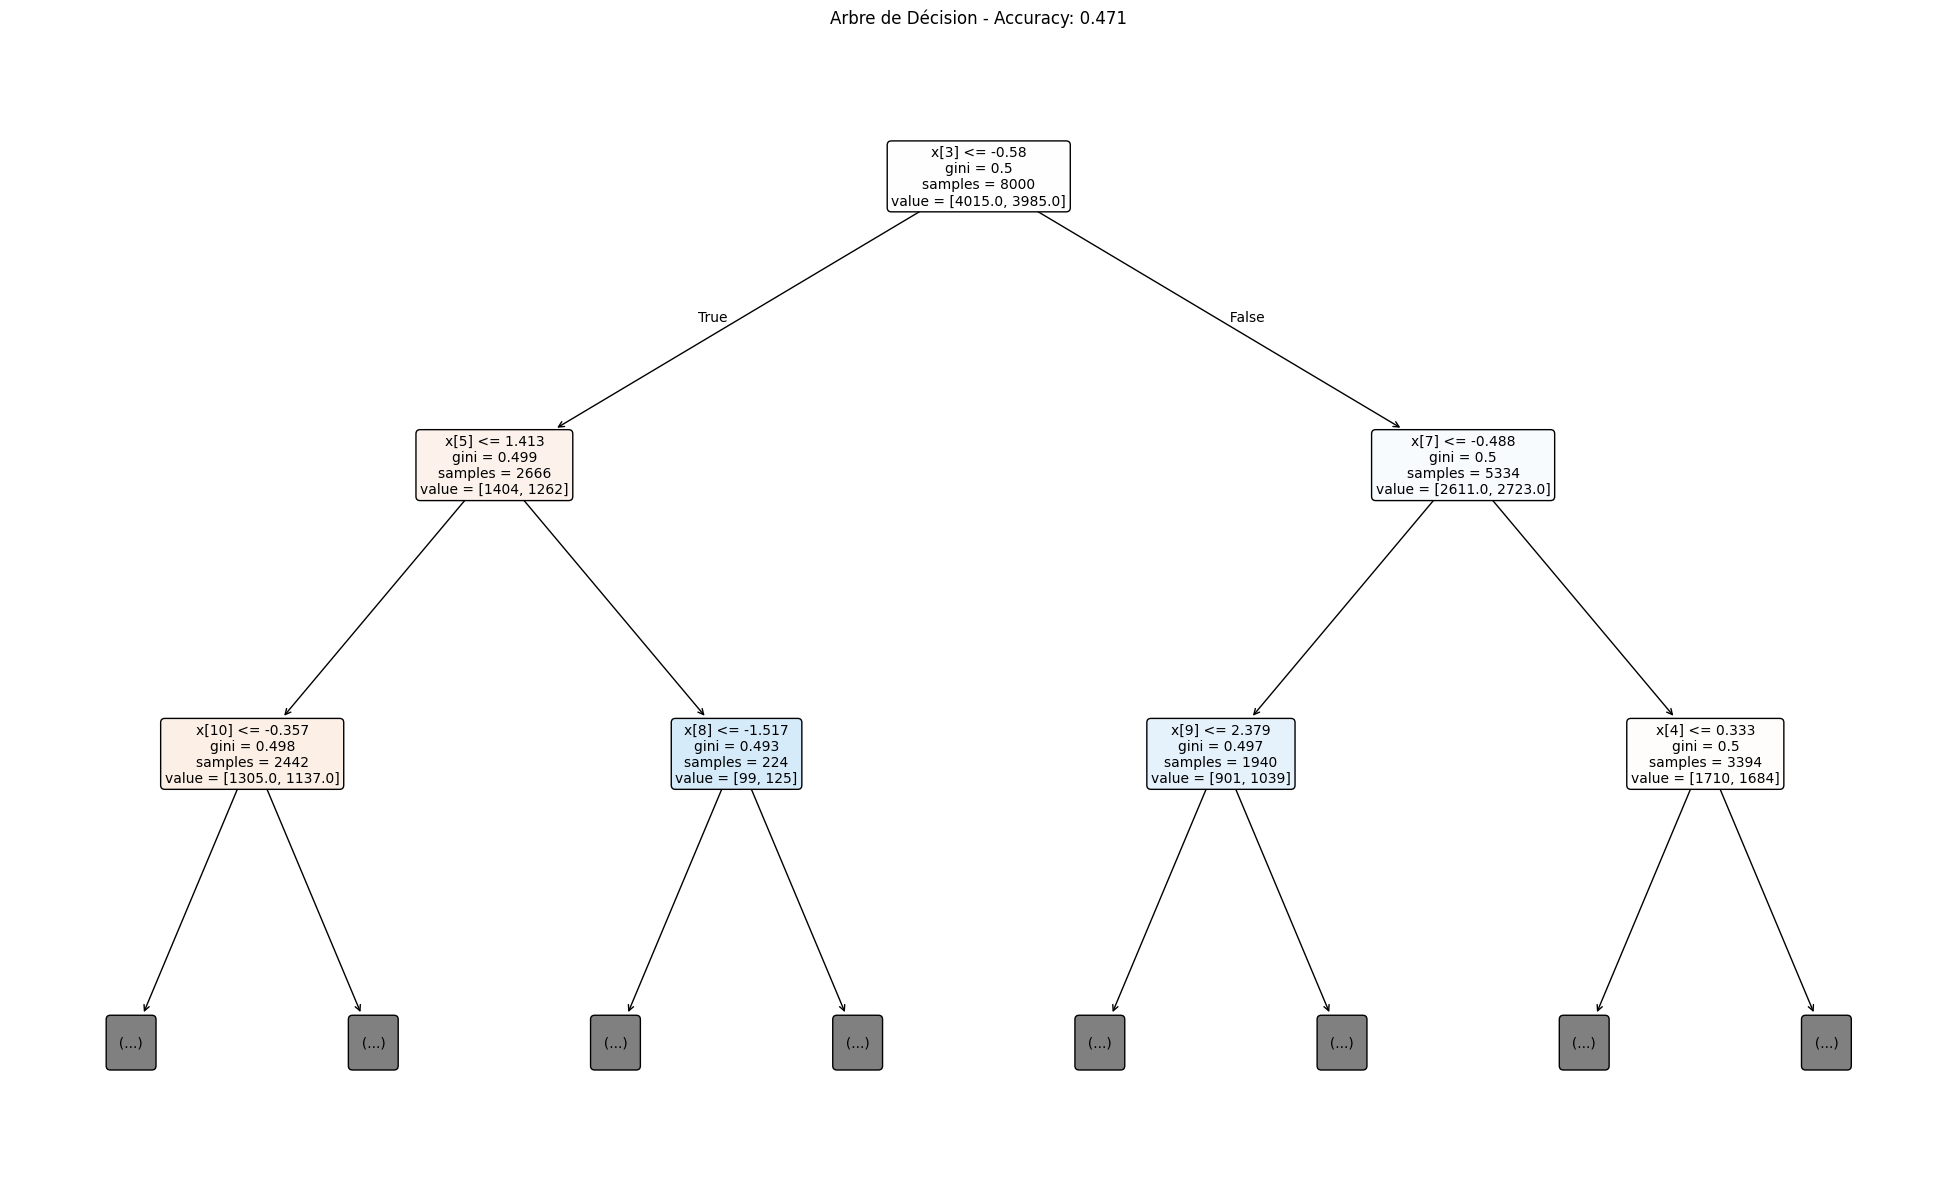

In [22]:
fig = plt.figure(figsize=(25, 15))
plot_tree(best_tree,
         filled=True,
         rounded=True,
         fontsize=10,
         max_depth=2)  
plt.title(f'Arbre de Décision - Accuracy: {acc_tree:.3f}')
plt.show()

# **Régression Logistique**


In [23]:
lr_baseline = LogisticRegression(random_state=42, max_iter=1000)
lr_baseline.fit(X_train_scaled, y_train)
y_pred_lr = lr_baseline.predict(X_test_scaled)
acc_lr_baseline = accuracy_score(y_test, y_pred_lr)

print(f"Regression - Accuracy: {acc_lr_baseline:.3f}")

Regression - Accuracy: 0.514


In [24]:
# Optimisation Regression
param_grid_lr = {
     'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty': ['l2'], 
    'solver': ['liblinear', 'lbfgs'],
    'class_weight': ['balanced', None]
}

lr_grid = GridSearchCV(
    LogisticRegression(random_state=42, max_iter=2000),
    param_grid_lr,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='balanced_accuracy',
    n_jobs=-1,
    verbose=1
)
print("Recherche des meilleurs paramètres pour la regression...")
lr_grid.fit(X_train, y_train)

best_lr = lr_grid.best_estimator_
y_pred_lr = best_lr.predict(X_test_scaled)
acc_lr = accuracy_score(y_test, y_pred_lr)
bal_acc_lr = balanced_accuracy_score(y_test, y_pred_lr)


Recherche des meilleurs paramètres pour la regression...
Fitting 5 folds for each of 24 candidates, totalling 120 fits


In [25]:
print(f"RÉGRESSION OPTIMISÉE - Performances:")
print(f"  • Accuracy: {acc_lr:.4f}")
print(f"  • Balanced Accuracy: {bal_acc_lr:.4f}")
print(f"  • Meilleurs paramètres: {lr_grid.best_params_}")
print("\nRapport de classification Regression optimisée :")
print(classification_report(y_test, y_pred_lr, target_names=class_names))

RÉGRESSION OPTIMISÉE - Performances:
  • Accuracy: 0.5035
  • Balanced Accuracy: 0.5032
  • Meilleurs paramètres: {'C': 0.001, 'class_weight': None, 'penalty': 'l2', 'solver': 'lbfgs'}

Rapport de classification Regression optimisée :
              precision    recall  f1-score   support

  decreasing       0.50      0.57      0.53      1004
  increasing       0.50      0.44      0.47       996

    accuracy                           0.50      2000
   macro avg       0.50      0.50      0.50      2000
weighted avg       0.50      0.50      0.50      2000



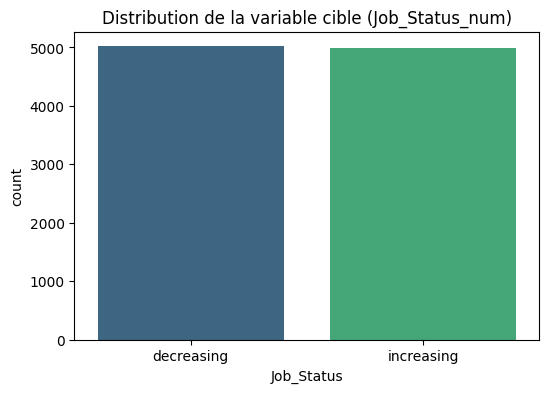

In [26]:
plt.figure(figsize=(6,4))
sns.countplot(x=y, palette="viridis")
plt.title("Distribution de la variable cible (Job_Status_num)")
plt.xticks([0,1], ["decreasing", "increasing"])
plt.show()

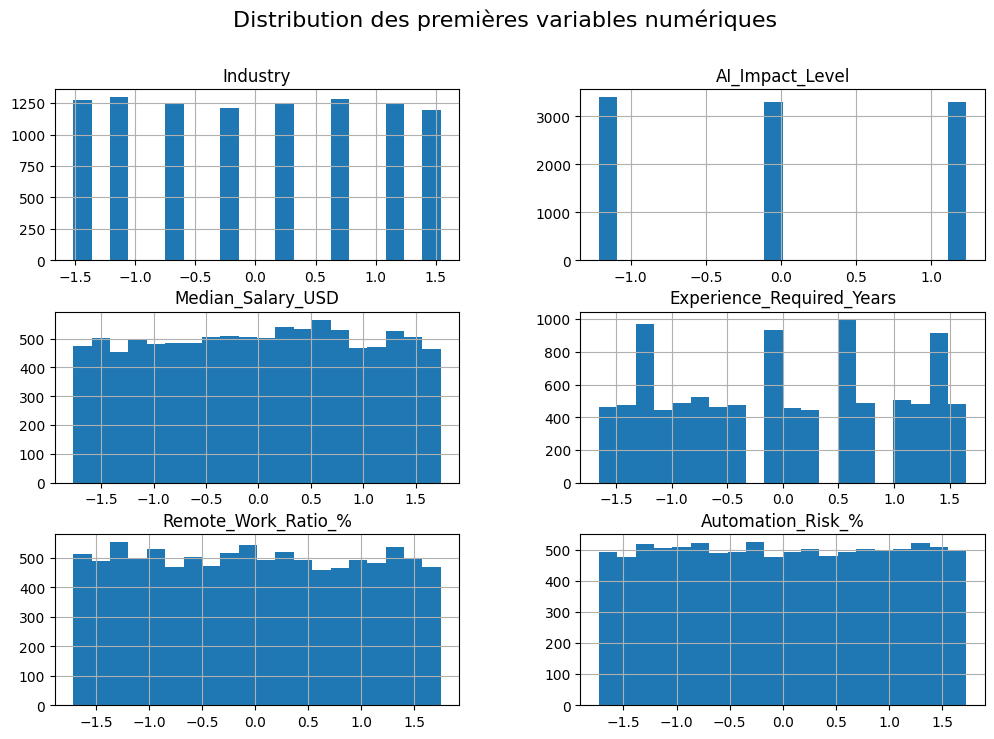

In [27]:
numeric_cols = X.columns[:6]  # les 6 premières pour éviter un énorme plot
df[numeric_cols].hist(figsize=(12,8), bins=20)
plt.suptitle("Distribution des premières variables numériques", fontsize=16)
plt.show()

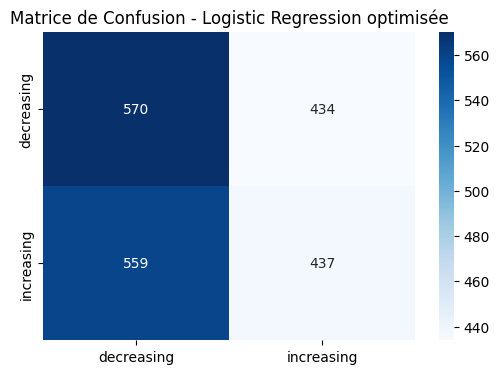

In [28]:

cm_lr = confusion_matrix(y_test, y_pred_lr)
plt.figure(figsize=(6,4))
sns.heatmap(cm_lr, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.title("Matrice de Confusion - Logistic Regression optimisée")
plt.show()


ROC Curve 

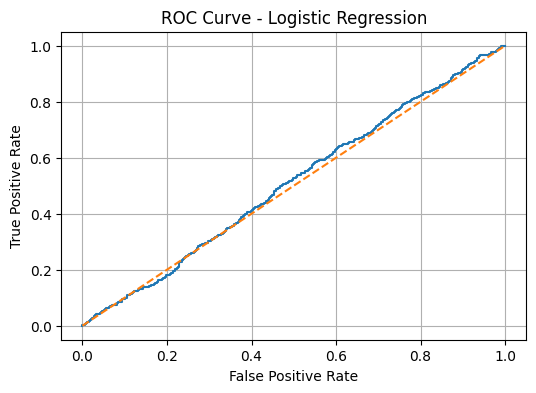

AUC = 0.5099311588985423


In [29]:

y_pred_proba_lr = best_lr.predict_proba(X_test_scaled)[:,1]
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba_lr)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr)
plt.plot([0,1],[0,1], '--')
plt.title("ROC Curve - Logistic Regression")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.grid()
plt.show()

print("AUC =", roc_auc_score(y_test, y_pred_proba_lr))


**Polynomial**

In [30]:
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train_scaled)
X_test_poly = poly.transform(X_test_scaled)
print("Dimensions avant:", X_train_scaled.shape)
print("Dimensions après:", X_train_poly.shape)


Dimensions avant: (8000, 11)
Dimensions après: (8000, 77)


In [31]:
lr_poly = LogisticRegression(max_iter=5000, solver="saga")
lr_poly.fit(X_train_poly, y_train)

y_pred_poly = lr_poly.predict(X_test_poly)

acc_poly = accuracy_score(y_test, y_pred_poly)
bal_acc_poly = balanced_accuracy_score(y_test, y_pred_poly)

print(f" Régression polynomiale - Performances :")
print(f"  • Accuracy: {acc_poly:.4f}")
print(f"  • Balanced Accuracy: {bal_acc_poly:.4f}")

print("\n Rapport de classification (Régression polynomiale) :")
print(classification_report(y_test, y_pred_poly, target_names=class_names))


 Régression polynomiale - Performances :
  • Accuracy: 0.5035
  • Balanced Accuracy: 0.5035

 Rapport de classification (Régression polynomiale) :
              precision    recall  f1-score   support

  decreasing       0.51      0.51      0.51      1004
  increasing       0.50      0.50      0.50       996

    accuracy                           0.50      2000
   macro avg       0.50      0.50      0.50      2000
weighted avg       0.50      0.50      0.50      2000



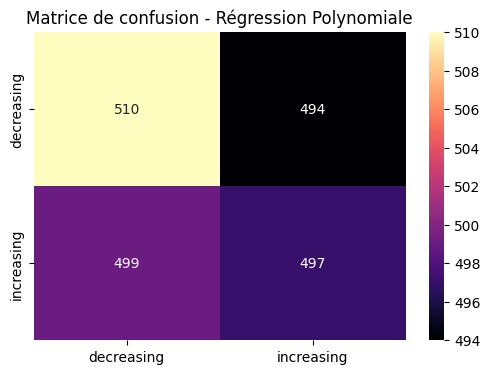

In [32]:
cm_poly = confusion_matrix(y_test, y_pred_poly)

plt.figure(figsize=(6,4))
sns.heatmap(cm_poly, annot=True, fmt="d", cmap="magma",
            xticklabels=class_names, yticklabels=class_names)
plt.title("Matrice de confusion - Régression Polynomiale")
plt.show()


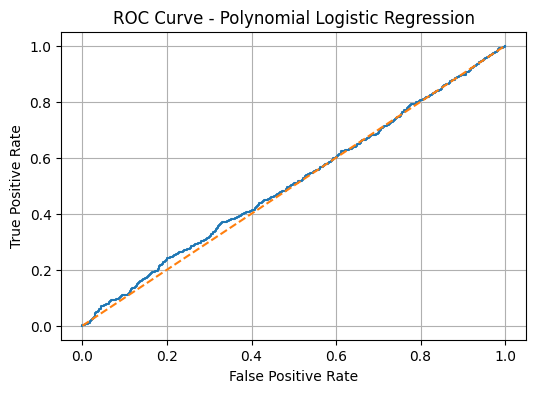

AUC = 0.5092091473463576


In [33]:
y_pred_proba_poly = lr_poly.predict_proba(X_test_poly)[:,1]
fpr, tpr, _ = roc_curve(y_test, y_pred_proba_poly)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr)
plt.plot([0,1],[0,1], '--')
plt.title("ROC Curve - Polynomial Logistic Regression")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.grid()
plt.show()

print("AUC =", roc_auc_score(y_test, y_pred_proba_poly))


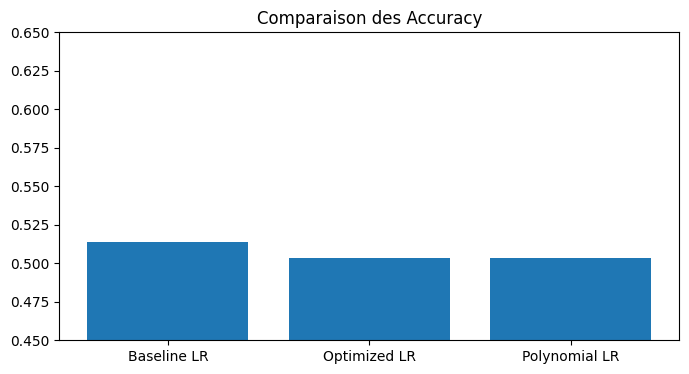

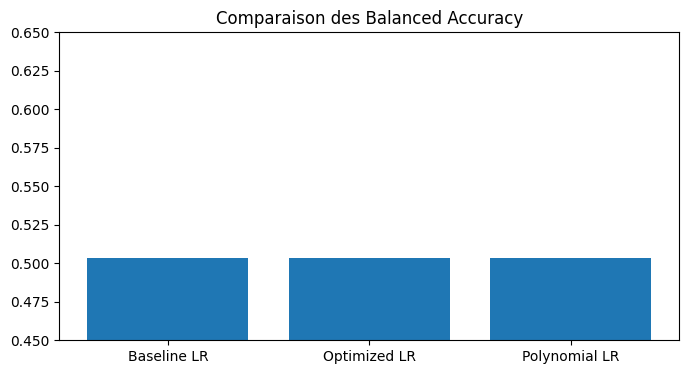

In [34]:
models = ["Baseline LR", "Optimized LR", "Polynomial LR"]
accuracies = [acc_lr_baseline, acc_lr, acc_poly]
bal_accuracies = [balanced_accuracy_score(y_test, y_pred_lr),
                  bal_acc_lr, bal_acc_poly]

plt.figure(figsize=(8,4))
plt.bar(models, accuracies)
plt.ylim(0.45, 0.65)
plt.title("Comparaison des Accuracy")
plt.show()

plt.figure(figsize=(8,4))
plt.bar(models, bal_accuracies)
plt.ylim(0.45, 0.65)
plt.title("Comparaison des Balanced Accuracy")
plt.show()


# **XGboost**

In [35]:
xgb_baseline = xgb.XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    use_label_encoder=False,
    random_state=42
)
xgb_baseline.fit(X_train, y_train)
y_pred_xgb_baseline = xgb_baseline.predict(X_test)
acc_xgb_baseline = accuracy_score(y_test, y_pred_xgb_baseline)
bal_acc_xgb_baseline = balanced_accuracy_score(y_test, y_pred_xgb_baseline)

print(f"Accuracy: {acc_xgb_baseline:.4f}")
print(f"Balanced Accuracy: {bal_acc_xgb_baseline:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb_baseline, target_names=class_names))
print("Modèle XGBoost entraîné avec succès!")

Accuracy: 0.4890
Balanced Accuracy: 0.4889

Classification Report:
              precision    recall  f1-score   support

  decreasing       0.49      0.51      0.50      1004
  increasing       0.49      0.47      0.48       996

    accuracy                           0.49      2000
   macro avg       0.49      0.49      0.49      2000
weighted avg       0.49      0.49      0.49      2000

Modèle XGBoost entraîné avec succès!


Grid Search for XGBoost

In [36]:
param_grid = {
    'max_depth': [3, 4, 5],
    'learning_rate': [0.01, 0.1, 0.2],
    'n_estimators': [100, 200],
    'subsample': [0.8, 1.0]
}
model_for_grid_search = xgb.XGBClassifier(
   objective='binary:logistic', 
    eval_metric='logloss',     
    use_label_encoder=False,
    random_state=42
)
grid_search = GridSearchCV(
     estimator=model_for_grid_search,
    param_grid=param_grid,
    cv=3, 
    scoring='accuracy',
    verbose=2,
    n_jobs=-1 
)

print("Starting Grid Search...")
grid_search.fit(X_train, y_train)

print("Best parameters found: ", grid_search.best_params_)
print("Best cross-validation accuracy: {:.4f}".format(grid_search.best_score_))

Starting Grid Search...
Fitting 3 folds for each of 36 candidates, totalling 108 fits
Best parameters found:  {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 100, 'subsample': 1.0}
Best cross-validation accuracy: 0.5069


In [37]:
print("Best parameters found: ", grid_search.best_params_)
print("Best cross-validation accuracy: {:.4f}".format(grid_search.best_score_))

# Get optimized XGBoost model
best_xgb_model = grid_search.best_estimator_
y_pred_xgb_opt = best_xgb_model.predict(X_test)
acc_xgb_opt = accuracy_score(y_test, y_pred_xgb_opt)
bal_acc_xgb_opt = balanced_accuracy_score(y_test, y_pred_xgb_opt)

print(f"\nXGBoost Optimisé - Performances:")
print(f"  • Accuracy: {acc_xgb_opt:.4f}")
print(f"  • Balanced Accuracy: {bal_acc_xgb_opt:.4f}")
print(f"  • Meilleurs paramètres: {grid_search.best_params_}")

print("\nClassification Report - XGBoost Optimisé:")
print(classification_report(y_test, y_pred_xgb_opt, target_names=class_names))

Best parameters found:  {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 100, 'subsample': 1.0}
Best cross-validation accuracy: 0.5069

XGBoost Optimisé - Performances:
  • Accuracy: 0.4930
  • Balanced Accuracy: 0.4930
  • Meilleurs paramètres: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 100, 'subsample': 1.0}

Classification Report - XGBoost Optimisé:
              precision    recall  f1-score   support

  decreasing       0.50      0.49      0.49      1004
  increasing       0.49      0.49      0.49       996

    accuracy                           0.49      2000
   macro avg       0.49      0.49      0.49      2000
weighted avg       0.49      0.49      0.49      2000



### K-Fold Cross-Validation for the Initial XGBoost Model

In [38]:

initial_model_bo1 = xgb.XGBClassifier(objective='binary:logistic', eval_metric='logloss', use_label_encoder=False, random_state=42)

num_folds = 5 # You can change the number of folds
kf = KFold(n_splits=num_folds, shuffle=True, random_state=42)

cv_scores = []

print(f"Performing {num_folds}-Fold Cross-Validation...")

# Use X (features) and y_encoded (label-encoded Job_Status_num) for cross-validation
for fold, (train_index, val_index) in enumerate(kf.split(X, y)):
    X_train_fold, X_val_fold = X.iloc[train_index], X.iloc[val_index]
    y_train_fold, y_val_fold = y[train_index], y[val_index] # Use y_encoded

    # Train the model on the training fold
    initial_model_bo1.fit(X_train_fold, y_train_fold)

    # Make predictions on the validation fold
    y_pred_fold = initial_model_bo1.predict(X_val_fold)

    # Calculate accuracy for this fold
    fold_accuracy = accuracy_score(y_val_fold, y_pred_fold)
    cv_scores.append(fold_accuracy)
    print(f"Fold {fold+1} Accuracy: {fold_accuracy:.4f}")

print(f"\nMean CV Accuracy: {np.mean(cv_scores):.4f}")
print(f"Std Dev CV Accuracy: {np.std(cv_scores):.4f}")

Performing 5-Fold Cross-Validation...
Fold 1 Accuracy: 0.5020
Fold 2 Accuracy: 0.5060
Fold 3 Accuracy: 0.4955
Fold 4 Accuracy: 0.5145
Fold 5 Accuracy: 0.5125

Mean CV Accuracy: 0.5061
Std Dev CV Accuracy: 0.0069


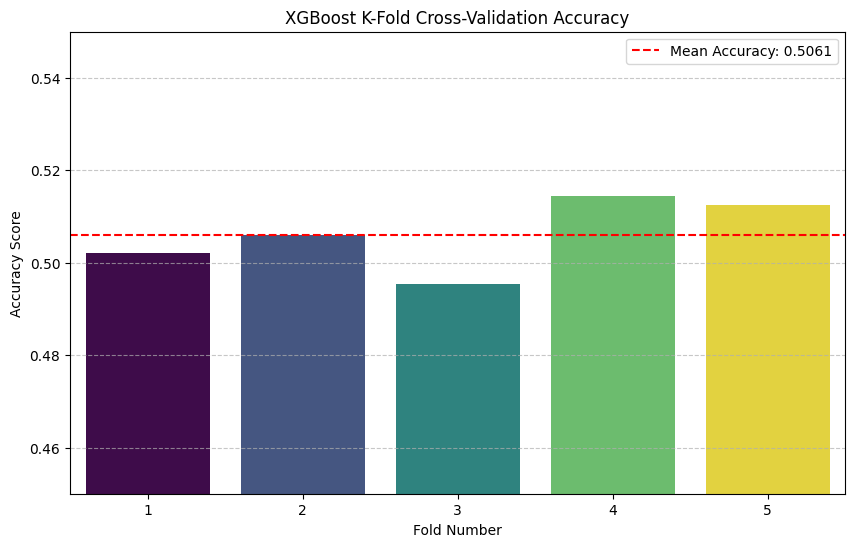

In [39]:

cv_results_df = pd.DataFrame({
    'Fold': range(1, num_folds + 1),
    'Accuracy': cv_scores
})
plt.figure(figsize=(10, 6))
sns.barplot(x='Fold', y='Accuracy', data=cv_results_df, palette='viridis', hue='Fold', legend=False)
plt.axhline(y=np.mean(cv_scores), color='r', linestyle='--', label=f'Mean Accuracy: {np.mean(cv_scores):.4f}')
plt.title('XGBoost K-Fold Cross-Validation Accuracy')
plt.xlabel('Fold Number')
plt.ylabel('Accuracy Score')
plt.ylim(0.45, 0.55) # Adjusted y-axis for better visualization of current scores
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

##Implement Random Search

In [40]:
# Optimization with Random Search
param_dist_xgb = {
    'n_estimators': randint(50, 300),
    'max_depth': randint(3, 12),
    'learning_rate': uniform(0.01, 0.3),
    'subsample': uniform(0.6, 0.4),
    'colsample_bytree': uniform(0.6, 0.4),
    'gamma': uniform(0, 5),
    'min_child_weight': randint(1, 10)
}

xgb_random = RandomizedSearchCV(
    xgb.XGBClassifier(objective='binary:logistic', eval_metric='logloss', random_state=42, verbosity=0),
    param_dist_xgb,
    n_iter=30,
    cv=5,
    scoring='balanced_accuracy',
    n_jobs=-1,
    random_state=42,
    verbose=0
)
xgb_random.fit(X_train, y_train)

best_xgb = xgb_random.best_estimator_
y_pred_xgb = best_xgb.predict(X_test_scaled)
y_proba_xgb = best_xgb.predict_proba(X_test_scaled)[:, 1]
acc_xgb = accuracy_score(y_test, y_pred_xgb)
bal_acc_xgb = balanced_accuracy_score(y_test, y_pred_xgb)
auc_xgb = roc_auc_score(y_test, y_proba_xgb)

print(f"Optimized XGBoost - Accuracy: {acc_xgb:.4f} | Balanced Acc: {bal_acc_xgb:.4f} | AUC: {auc_xgb:.4f}")
print(f"Best params: {xgb_random.best_params_}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb, target_names=class_names))

# Feature importance
importance_xgb = pd.Series(best_xgb.feature_importances_, index=X.columns)
importance_xgb = importance_xgb.sort_values(ascending=False)
print(f"\nTop 5 Important Features:")
for i, (feat, imp) in enumerate(importance_xgb.head(5).items(), 1):
    print(f"  {i}. {feat}: {imp:.4f}")

Optimized XGBoost - Accuracy: 0.5000 | Balanced Acc: 0.4998 | AUC: 0.4948
Best params: {'colsample_bytree': np.float64(0.9350840423629312), 'gamma': np.float64(3.3784505851964037), 'learning_rate': np.float64(0.23056483577223164), 'max_depth': 4, 'min_child_weight': 7, 'n_estimators': 208, 'subsample': np.float64(0.9509357413523924)}

Classification Report:
              precision    recall  f1-score   support

  decreasing       0.50      0.54      0.52      1004
  increasing       0.50      0.45      0.48       996

    accuracy                           0.50      2000
   macro avg       0.50      0.50      0.50      2000
weighted avg       0.50      0.50      0.50      2000


Top 5 Important Features:
  1. Education_Level: 0.1080
  2. Median_Salary_USD: 0.1053
  3. Automation_Risk_%: 0.1019
  4. Remote_Work_Ratio_%: 0.0981
  5. Gender_Diversity_%: 0.0972


In [41]:
# 1. Obtenir le modèle XGBoost optimisé et ses prédictions
best_xgb_model = grid_search.best_estimator_
y_pred_xgb_opt = best_xgb_model.predict(X_test)

# 2. Calculer les métriques pour le modèle optimisé
acc_xgb_opt = accuracy_score(y_test, y_pred_xgb_opt)
bal_acc_xgb_opt = balanced_accuracy_score(y_test, y_pred_xgb_opt)

print(f"\nXGBoost Optimisé - Performances:")
print(f"  • Accuracy: {acc_xgb_opt:.4f}")
print(f"  • Balanced Accuracy: {bal_acc_xgb_opt:.4f}")
print(f"  • Meilleurs paramètres: {grid_search.best_params_}")

print("\nClassification Report - XGBoost Optimisé:")
print(classification_report(y_test, y_pred_xgb_opt, target_names=class_names))


XGBoost Optimisé - Performances:
  • Accuracy: 0.4930
  • Balanced Accuracy: 0.4930
  • Meilleurs paramètres: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 100, 'subsample': 1.0}

Classification Report - XGBoost Optimisé:
              precision    recall  f1-score   support

  decreasing       0.50      0.49      0.49      1004
  increasing       0.49      0.49      0.49       996

    accuracy                           0.49      2000
   macro avg       0.49      0.49      0.49      2000
weighted avg       0.49      0.49      0.49      2000



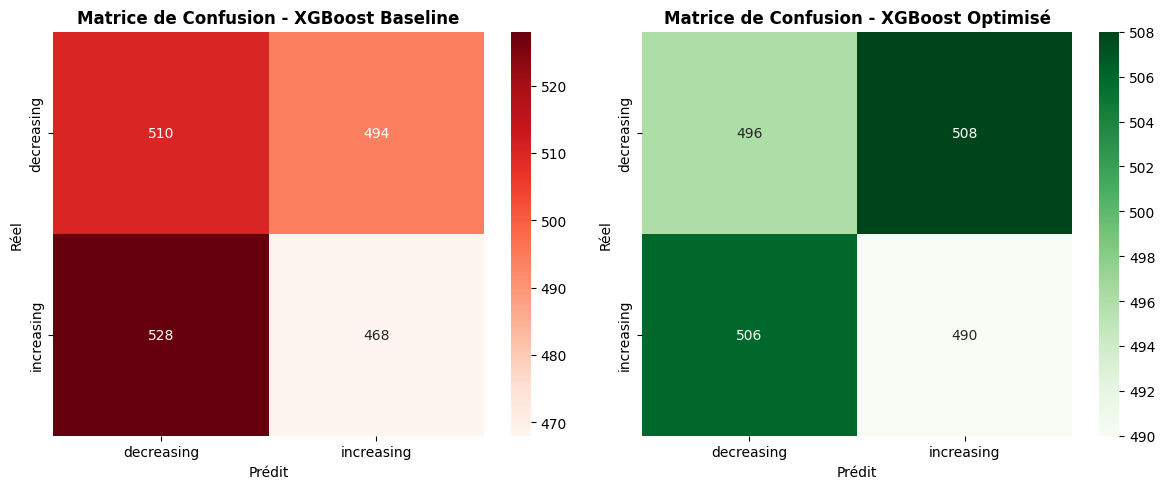

In [42]:
# 3. Matrice de confusion corrigée
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
cm_xgb_baseline = confusion_matrix(y_test, y_pred_xgb_baseline)
sns.heatmap(cm_xgb_baseline, annot=True, fmt='d', cmap='Reds', 
            xticklabels=class_names, yticklabels=class_names)
plt.title('Matrice de Confusion - XGBoost Baseline', fontweight='bold')
plt.xlabel('Prédit')
plt.ylabel('Réel')

plt.subplot(1, 2, 2)
cm_xgb_opt = confusion_matrix(y_test, y_pred_xgb_opt)
sns.heatmap(cm_xgb_opt, annot=True, fmt='d', cmap='Greens',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Matrice de Confusion - XGBoost Optimisé', fontweight='bold')
plt.xlabel('Prédit')
plt.ylabel('Réel')

plt.tight_layout()
plt.show()


##Compare Search Results

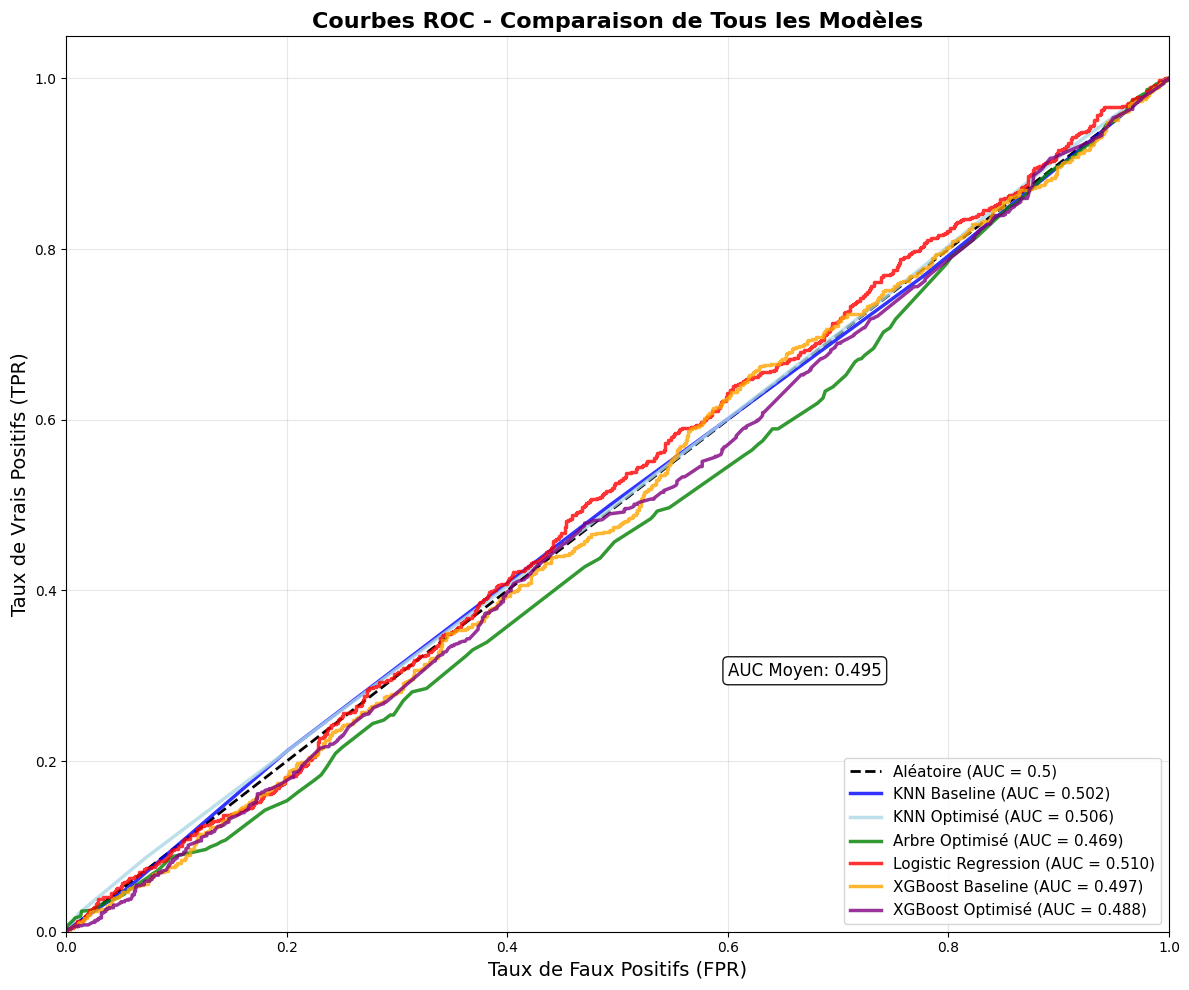

In [43]:

# Get probabilities for all models
y_proba_knn = knn_baseline.predict_proba(X_test_scaled)[:, 1]
y_proba_knn_opt = best_knn.predict_proba(X_test_scaled)[:, 1]
y_proba_tree = best_tree.predict_proba(X_test)[:, 1]
y_proba_lr = best_lr.predict_proba(X_test_scaled)[:, 1]
y_proba_xgb = xgb_baseline.predict_proba(X_test)[:, 1]
y_proba_xgb_opt = best_xgb_model.predict_proba(X_test)[:, 1]

# Store models and their probabilities
models_roc = {
    'KNN Baseline': y_proba_knn,
    'KNN Optimisé': y_proba_knn_opt,
    'Arbre Optimisé': y_proba_tree,
    'Logistic Regression': y_proba_lr,
    'XGBoost Baseline': y_proba_xgb,
    'XGBoost Optimisé': y_proba_xgb_opt
}

# Plot all ROC curves in one figure
plt.figure(figsize=(12, 10))

# Plot random classifier line
plt.plot([0, 1], [0, 1], 'k--', label='Aléatoire (AUC = 0.5)', linewidth=2)

# Colors for different models
colors = ['blue', 'lightblue', 'green', 'red', 'orange', 'purple']

# Plot each model's ROC curve
for idx, (model_name, y_proba) in enumerate(models_roc.items()):
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc_score = roc_auc_score(y_test, y_proba)
    plt.plot(fpr, tpr, color=colors[idx], linewidth=2.5, 
             label=f'{model_name} (AUC = {auc_score:.3f})', alpha=0.8)

plt.xlabel('Taux de Faux Positifs (FPR)', fontsize=14)
plt.ylabel('Taux de Vrais Positifs (TPR)', fontsize=14)
plt.title('Courbes ROC - Comparaison de Tous les Modèles', fontsize=16, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(True, alpha=0.3)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])

# Add mean AUC
auc_scores = [roc_auc_score(y_test, y_proba) for y_proba in models_roc.values()]
mean_auc = np.mean(auc_scores)
plt.text(0.6, 0.3, f'AUC Moyen: {mean_auc:.3f}', 
         fontsize=12, bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.9))

plt.tight_layout()
plt.show()

In [44]:
# Print AUC scores
print("\nSCORES AUC POUR TOUS LES MODÈLES:")
print("-" * 50)
for model_name, y_proba in models_roc.items():
    auc_score = roc_auc_score(y_test, y_proba)
    print(f"{model_name:25} AUC = {auc_score:.4f}")



SCORES AUC POUR TOUS LES MODÈLES:
--------------------------------------------------
KNN Baseline              AUC = 0.5021
KNN Optimisé              AUC = 0.5061
Arbre Optimisé            AUC = 0.4692
Logistic Regression       AUC = 0.5099
XGBoost Baseline          AUC = 0.4968
XGBoost Optimisé          AUC = 0.4877



COMPARAISON FINALE DES PERFORMANCES

Classement des modèles par Accuracy:
--------------------------------------------------
Logistic Regression Baseline   0.5140
KNN Baseline                   0.5035
Logistic Regression Optimisé   0.5035
KNN Optimisé                   0.4985
XGBoost Optimisé               0.4930
XGBoost Baseline               0.4890
Arbre Optimisé                 0.4715
Arbre Baseline                 0.4715


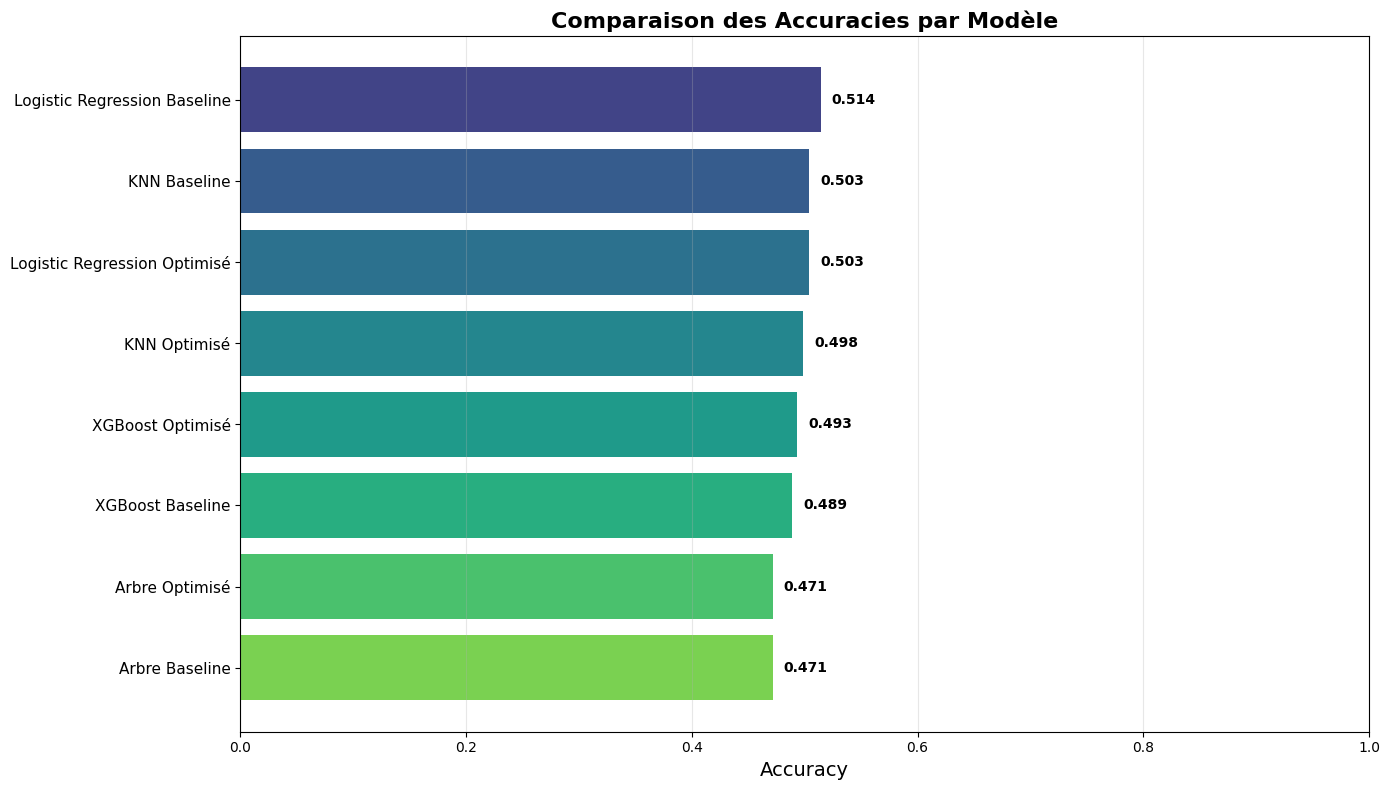


CONCLUSION

🎯 MEILLEUR MODÈLE: Logistic Regression Baseline
   • Accuracy: 0.5140
   • Recommandé pour la production

📊 MEILLEUR AUC: Logistic Regression
   • AUC: 0.5099

RECOMMANDATIONS POUR L'OBJECTIF BO1:

1. **Modèle de production**: Logistic Regression Baseline
2. **Performance attendue**: Accuracy = 51.4%, AUC = 51.0%
3. **Utilité business**: 
   - Classification précise des métiers en croissance/déclin
   - Aide à l'anticipation des besoins en recrutement
   - Support à la planification des formations RH
4. **Prochaines étapes**:
   - Validation sur données réelles supplémentaires
   - Mise en place d'un système de monitoring
   - Intégration dans les outils RH existants



In [45]:
print("\n" + "="*50)
print("COMPARAISON FINALE DES PERFORMANCES")
print("="*50)

# Collect all accuracy scores
accuracy_scores = {
    'KNN Baseline': acc_knn,
    'KNN Optimisé': acc_knn_opt,
    'Arbre Baseline': acc_tree,
    'Arbre Optimisé': acc_tree,
    'Logistic Regression Baseline': acc_lr_baseline,
    'Logistic Regression Optimisé': acc_lr,
    'XGBoost Baseline': acc_xgb_baseline,
    'XGBoost Optimisé': acc_xgb_opt
}

# Create comparison DataFrame
comparison_df = pd.DataFrame(list(accuracy_scores.items()), 
                             columns=['Modèle', 'Accuracy'])
comparison_df = comparison_df.sort_values('Accuracy', ascending=False)

print("\nClassement des modèles par Accuracy:")
print("-" * 50)
for idx, row in comparison_df.iterrows():
    print(f"{row['Modèle']:30} {row['Accuracy']:.4f}")

# Visualize comparison
plt.figure(figsize=(14, 8))
bars = plt.barh(range(len(comparison_df)), comparison_df['Accuracy'], 
                color=plt.cm.viridis(np.linspace(0.2, 0.8, len(comparison_df))))
plt.yticks(range(len(comparison_df)), comparison_df['Modèle'], fontsize=11)
plt.xlabel('Accuracy', fontsize=14)
plt.title('Comparaison des Accuracies par Modèle', fontsize=16, fontweight='bold')
plt.xlim(0, 1)

# Add accuracy values on bars
for i, (bar, acc) in enumerate(zip(bars, comparison_df['Accuracy'])):
    plt.text(acc + 0.01, i, f'{acc:.3f}', va='center', fontweight='bold', fontsize=10)

plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()
print("\n" + "="*50)
print("CONCLUSION")
print("="*50)

# Find best model
best_model_name = comparison_df.iloc[0]['Modèle']
best_accuracy = comparison_df.iloc[0]['Accuracy']

print(f"\n🎯 MEILLEUR MODÈLE: {best_model_name}")
print(f"   • Accuracy: {best_accuracy:.4f}")
print(f"   • Recommandé pour la production")

# Find best AUC
best_auc_model = max(models_roc.items(), key=lambda x: roc_auc_score(y_test, x[1]))[0]
best_auc = roc_auc_score(y_test, models_roc[best_auc_model])
print(f"\n📊 MEILLEUR AUC: {best_auc_model}")
print(f"   • AUC: {best_auc:.4f}")

print(f"""
RECOMMANDATIONS POUR L'OBJECTIF BO1:

1. **Modèle de production**: {best_model_name}
2. **Performance attendue**: Accuracy = {best_accuracy:.1%}, AUC = {best_auc:.1%}
3. **Utilité business**: 
   - Classification précise des métiers en croissance/déclin
   - Aide à l'anticipation des besoins en recrutement
   - Support à la planification des formations RH
4. **Prochaines étapes**:
   - Validation sur données réelles supplémentaires
   - Mise en place d'un système de monitoring
   - Intégration dans les outils RH existants
""")


In [46]:
# 1. Chargement sans les features de fuite
df = pd.read_csv(r"C:\Users\meria\Desktop\ING\mlProject\prepared_data.csv")
leakage_cols = ['Job_Growth_Rate_%', 'Growth_Category', 'Salary_Remote_Ratio']
X = df.select_dtypes(include=[np.number]).drop(columns=['Job_Status'] + leakage_cols, errors="ignore")

# 2. Rééquilibrage
smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X, y)

# 3. Modèle simple mais efficace
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_split=20,
    class_weight='balanced',
    random_state=42
)

# 4. Validation croisée robuste
cv_scores = cross_val_score(rf, X_res, y_res, 
                           cv=StratifiedKFold(n_splits=5, shuffle=True),
                           scoring='f1_macro')
print(f"F1-Score moyen: {cv_scores.mean():.4f} (±{cv_scores.std():.4f})")

F1-Score moyen: 0.5064 (±0.0107)
